In [250]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [294]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [295]:
#  Load Dataset 
df = pd.read_csv("airflight.csv")

# Preview dataset
print(df.head())

# Check missing values
print(df.isnull().sum())

# Drop missing rows
df = df.dropna()
df.fillna(method='ffill', inplace=True)

# Dataset info and stats
df.info()
print(df.describe())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time   

C:\Users\ky042\AppData\Local\Temp\ipykernel_8976\2193245507.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
          Unnamed: 0       duration      days_left          price
count  300153.000000  300153.000000  300153.000000  300153.000000
mean   150076.000000  

In [296]:
#  Explore Dataset
print(df['airline'].value_counts())
print(df['source_city'].value_counts())
print(df['departure_time'].value_counts())

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64


In [297]:
# Handle Date Column 
if 'Date_of_Journey' in df.columns:
    df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y', errors='coerce')
    df['Journey_day'] = df['Date_of_Journey'].dt.day
    df['Journey_month'] = df['Date_of_Journey'].dt.month

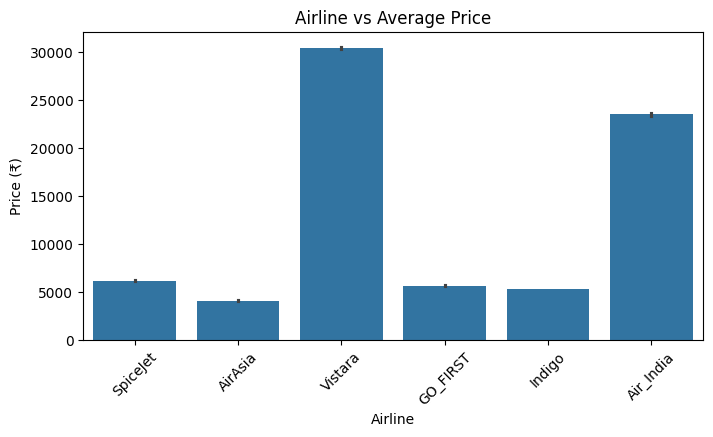

In [298]:
# ---------------- STEP 5: Visualizations ----------------
# Airline vs Price
plt.figure(figsize=(8,4))
sns.barplot(x='airline', y='price', data=df)
plt.title("Airline vs Average Price")
plt.ylabel("Price (₹)")
plt.xlabel("Airline")
plt.xticks(rotation=45)
plt.show()



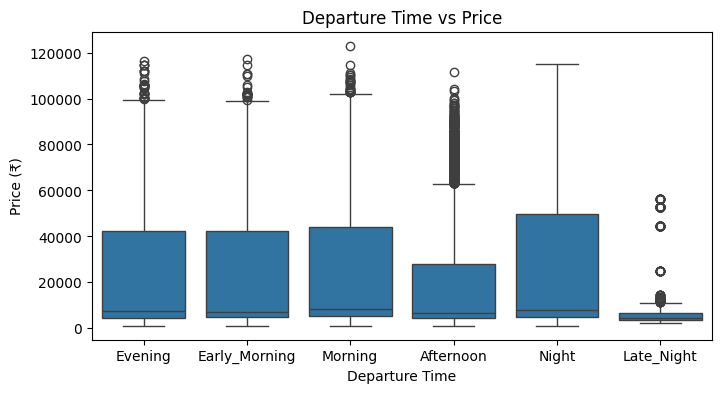

In [299]:
# Departure time vs Price
plt.figure(figsize=(8,4))
sns.boxplot(x='departure_time', y='price', data=df)
plt.title("Departure Time vs Price")
plt.ylabel("Price (₹)")
plt.xlabel("Departure Time")
plt.show()


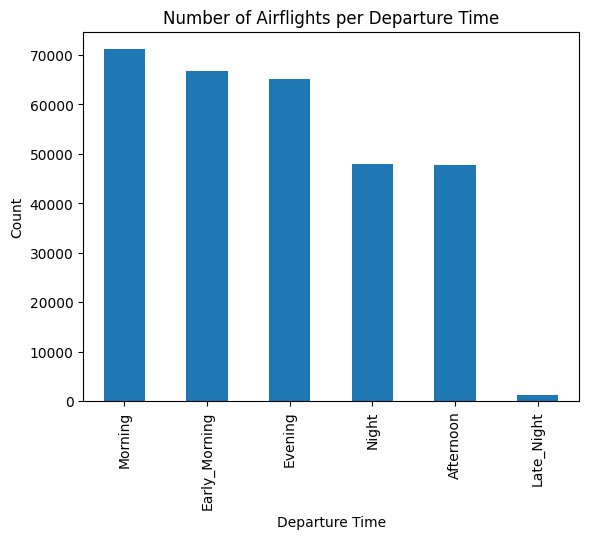

In [300]:
# Number of flights per departure time
df["departure_time"].value_counts().plot(kind="bar")
plt.title("Number of Airflights per Departure Time")
plt.xlabel("Departure Time")
plt.ylabel("Count")
plt.show()

In [301]:
# ---------------- STEP 6: Encode Categorical Columns ----------------
categorical_cols = ['airline', 'source_city', 'departure_time', 'destination_city', 'flight']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Features and target
X = df_encoded.drop(['price'], axis=1)
y = df_encoded['price']

In [302]:
# ---------------- STEP 7: Split Data ----------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [303]:
# Missing values handle
df.fillna(method='ffill', inplace=True)

C:\Users\ky042\AppData\Local\Temp\ipykernel_8976\2597086053.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [304]:
print(df.columns)

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')


In [305]:
# Explore dataset
df['airline'].value_counts()

# Check source cities
df['source_city'].value_counts()

# Check departure times
df['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [306]:
df.sort_values(by="source_city")

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
109076,109076,Vistara,UK-818,Bangalore,Evening,one,Morning,Kolkata,Economy,12.67,45,8112
90813,90813,Air_India,AI-738,Bangalore,Morning,one,Night,Delhi,Economy,9.08,34,4792
90812,90812,AirAsia,I5-818,Bangalore,Early_Morning,one,Evening,Delhi,Economy,12.75,34,4570
90811,90811,AirAsia,I5-1982,Bangalore,Early_Morning,one,Afternoon,Delhi,Economy,8.25,34,4570
90810,90810,Indigo,6E-6386,Bangalore,Night,zero,Night,Delhi,Economy,3.00,34,4500
...,...,...,...,...,...,...,...,...,...,...,...,...
45334,45334,Air_India,AI-611,Mumbai,Morning,one,Morning,Delhi,Economy,21.33,14,9093
45335,45335,Air_India,AI-637,Mumbai,Evening,one,Night,Delhi,Economy,26.42,14,9303
45336,45336,Vistara,UK-653,Mumbai,Early_Morning,one,Evening,Delhi,Economy,10.50,14,9723
45310,45310,Air_India,AI-619,Mumbai,Night,one,Evening,Delhi,Economy,22.25,14,6391


In [307]:
# Handle missing values (if any)
df = df.dropna(subset=['price', 'days_left'])

# Convert categorical columns to numeric using one-hot encoding
categorical_cols = ['airline', 'source_city', 'departure_time', 'destination_city', 'flight']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [308]:
# Features and target
X = df_encoded.drop(['price'], axis=1)
y = df_encoded['price']

In [309]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [313]:
from sklearn.metrics import accuracy_score

In [314]:
y_true = [1, 0, 1, 1, 0]
y_pred = [1, 0, 0, 1, 0]

In [315]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


In [316]:
accuracy = accuracy_score(y_true, y_pred) * 100
print("Accuracy:", accuracy, "%")

Accuracy: 80.0 %
